# Banknote Authentication — Binary Classification Project
## Classifying Genuine vs Forged Banknotes

**Dataset**: Banknote Authentication (UCI ML Repository, ID=267)  
**Problem Type**: Binary Classification  
**Target Variable**: Class (0 = Forged, 1 = Genuine)  
**Algorithms**:
1. Logistic Regression
2. K-Nearest Neighbours (KNN)

**Goal**: Build and compare models to accurately classify whether a banknote is genuine or counterfeit based on image features.

---
## Step 1 — Import Dataset from UCI Repository

In [1]:
from ucimlrepo import fetch_ucirepo

# ── Fetch the Banknote Authentication dataset (ID = 267) ──
banknote_data = fetch_ucirepo(id=267)

# Separate features (X) and the target variable (y)
X_raw = banknote_data.data.features   # Image features
y_raw = banknote_data.data.targets    # Target: 0 = Forged, 1 = Genuine

print("Dataset fetched successfully!")
print(f"Features shape : {X_raw.shape}")
print(f"Target shape   : {y_raw.shape}")
print(f"\nTarget distribution:")
print(y_raw.value_counts())

Dataset fetched successfully!
Features shape : (1372, 4)
Target shape   : (1372, 1)

Target distribution:
class
0        762
1        610
Name: count, dtype: int64


---
## Step 2 — Import All Required Libraries

In [2]:
# -- Standard data manipulation --
import numpy as np
import pandas as pd

# -- Visualisation --
import matplotlib.pyplot as plt
import seaborn as sns

# -- Preprocessing --
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# -- Classification Algorithms --
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# -- Evaluation Metrics --
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)

# -- Reproducibility --
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# -- Make all plots look clean and professional --
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 3 — Exploratory Data Analysis (EDA)
### 3.1 Basic Overview

In [3]:
# -- Combine features and target into one DataFrame --
df = pd.concat([X_raw, y_raw], axis=1)

# Ensure consistent target column naming across all steps
if "Class" not in df.columns and "class" in df.columns:
    df = df.rename(columns={"class": "Class"})

print("=" * 60)
print(" DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples (banknotes)  : {df.shape[0]}")
print(f"Total features             : {df.shape[1] - 1}")
print()

print("--- First 5 rows ---")
display(df.head())

print("\n--- Data Types, Non-null, Missing ---")
overview_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-null Count": df.notna().sum().values,
    "Missing Count": df.isna().sum().values
})
display(overview_df)

print("\n--- Statistical Summary ---")
display(df.describe())

print("\n--- Missing Values Check ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values! Dataset is clean.")

 DATASET OVERVIEW
Total samples (banknotes)  : 1372
Total features             : 4

--- First 5 rows ---


,variance,skewness,curtosis,entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0



--- Data Types, Non-null, Missing ---


,Column,Data Type,Non-null Count,Missing Count
0,variance,float64,1372,0
1,skewness,float64,1372,0
2,curtosis,float64,1372,0
3,entropy,float64,1372,0
4,Class,int64,1372,0



--- Statistical Summary ---


,variance,skewness,curtosis,entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000



--- Missing Values Check ---
No missing values! Dataset is clean.


### 3.2 Target Variable Distribution

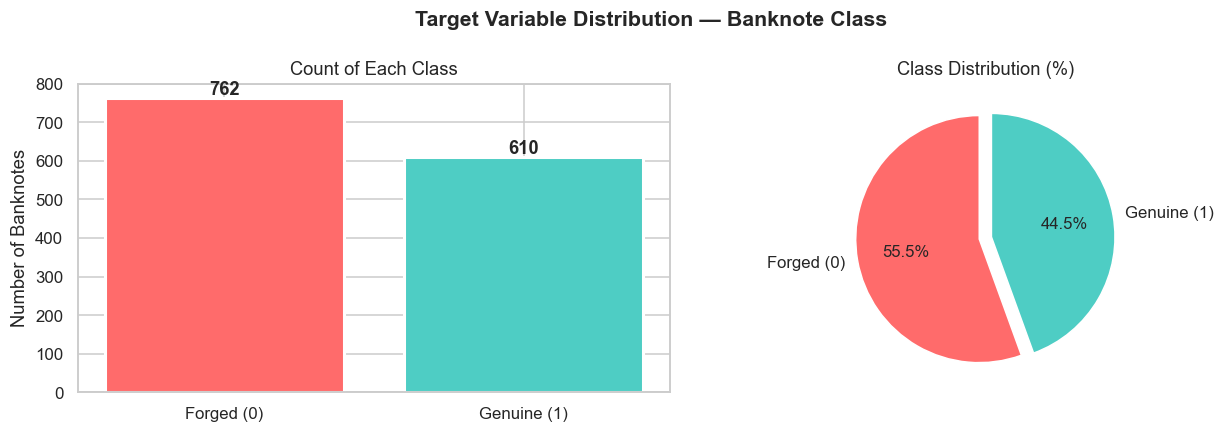

Forged banknotes   :  762 (55.5%)
Genuine banknotes  :  610 (44.5%)

Class Balance: 0.80x more genuine than forged


In [4]:
# ── Check class balance in the dataset ──

# Ensure target column name matches the rest of the notebook
if "Class" not in df.columns and "class" in df.columns:
    df = df.rename(columns={"class": "Class"})

class_counts = df["Class"].value_counts().sort_index()
class_labels = ["Forged (0)", "Genuine (1)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Target Variable Distribution — Banknote Class", fontsize=14, fontweight="bold")

# Bar chart
axes[0].bar(class_labels, class_counts.values, color=["#FF6B6B", "#4ECDC4"], edgecolor="white", linewidth=2)
axes[0].set_title("Count of Each Class")
axes[0].set_ylabel("Number of Banknotes")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie chart
colors = ["#FF6B6B", "#4ECDC4"]
axes[1].pie(class_counts.values, labels=class_labels, autopct="%1.1f%%", 
            colors=colors, startangle=90, explode=(0.05, 0.05), textprops={"fontsize": 11})
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

print(f"Forged banknotes   : {class_counts[0]:4d} ({class_counts[0]/len(df)*100:.1f}%)")
print(f"Genuine banknotes  : {class_counts[1]:4d} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"\nClass Balance: {class_counts[1]/class_counts[0]:.2f}x more genuine than forged")

### 3.3 Feature Distributions — Forged vs Genuine

Features: ['variance', 'skewness', 'curtosis', 'entropy']


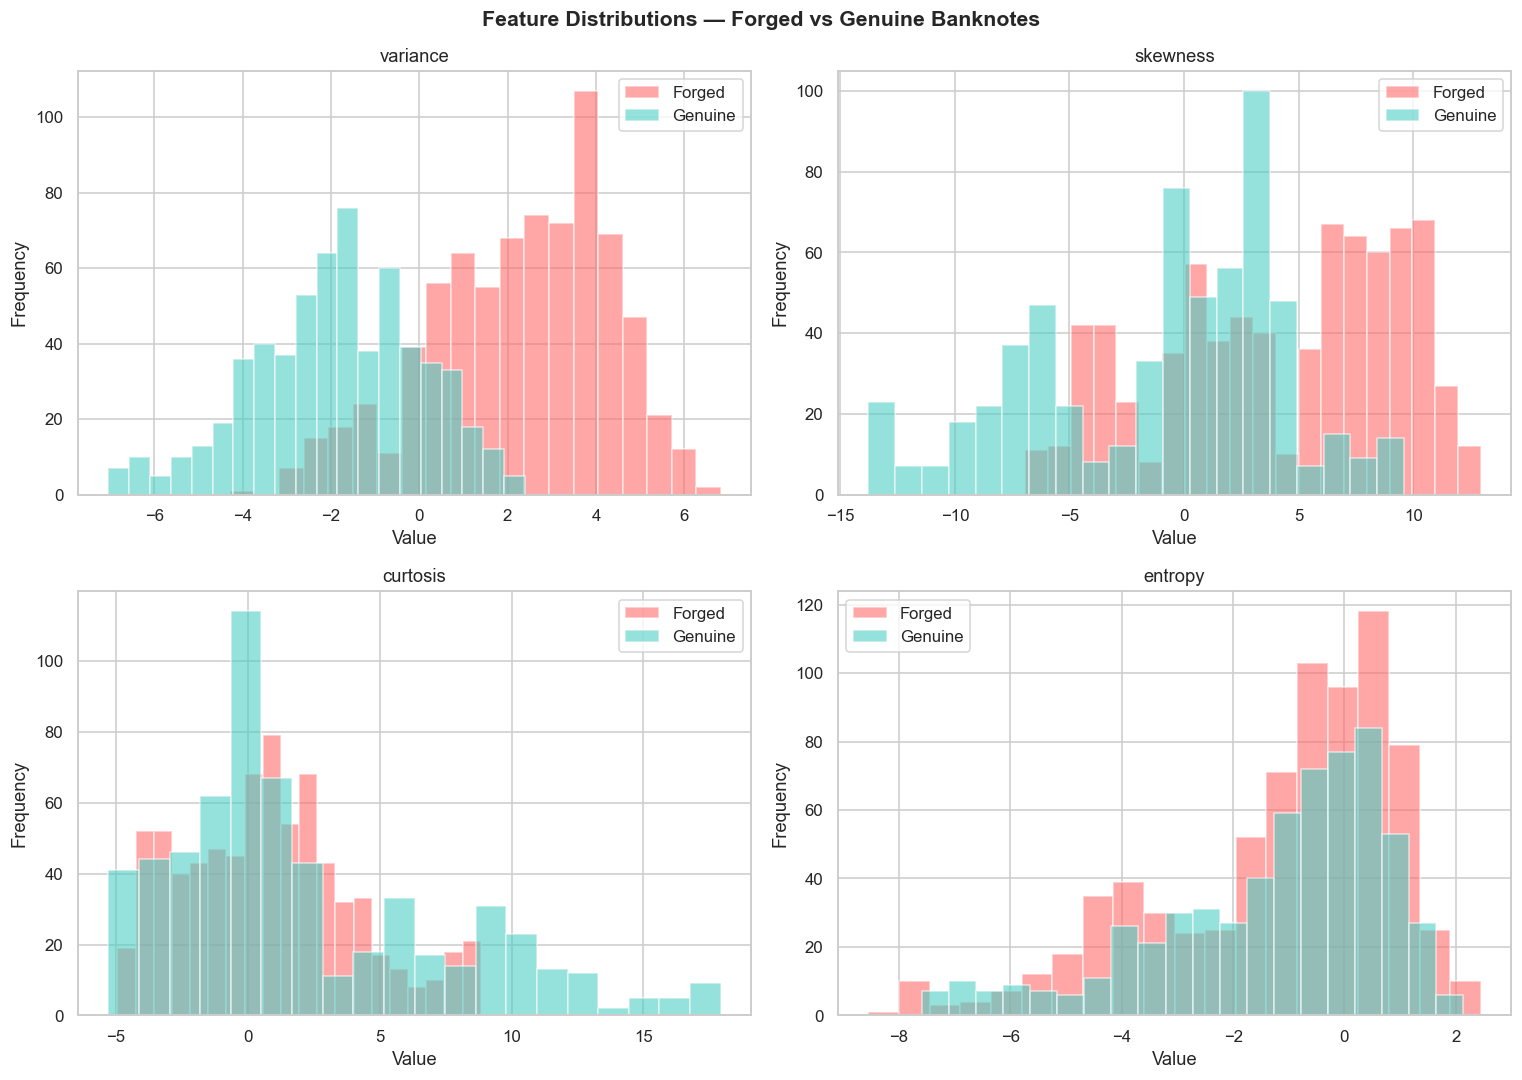

In [5]:
# ── Get feature names from the dataset ──
feature_names = X_raw.columns.tolist()
print(f"Features: {feature_names}")

# ── Plot histograms for each feature, split by class ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions — Forged vs Genuine Banknotes", fontsize=14, fontweight="bold")
axes = axes.flatten()

for idx, feature_name in enumerate(feature_names):
    forged_data = df[df["Class"] == 0][feature_name]
    genuine_data = df[df["Class"] == 1][feature_name]
    
    axes[idx].hist(forged_data, bins=20, alpha=0.6, label="Forged", color="#FF6B6B", edgecolor="white")
    axes[idx].hist(genuine_data, bins=20, alpha=0.6, label="Genuine", color="#4ECDC4", edgecolor="white")
    axes[idx].set_title(feature_name)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()

plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

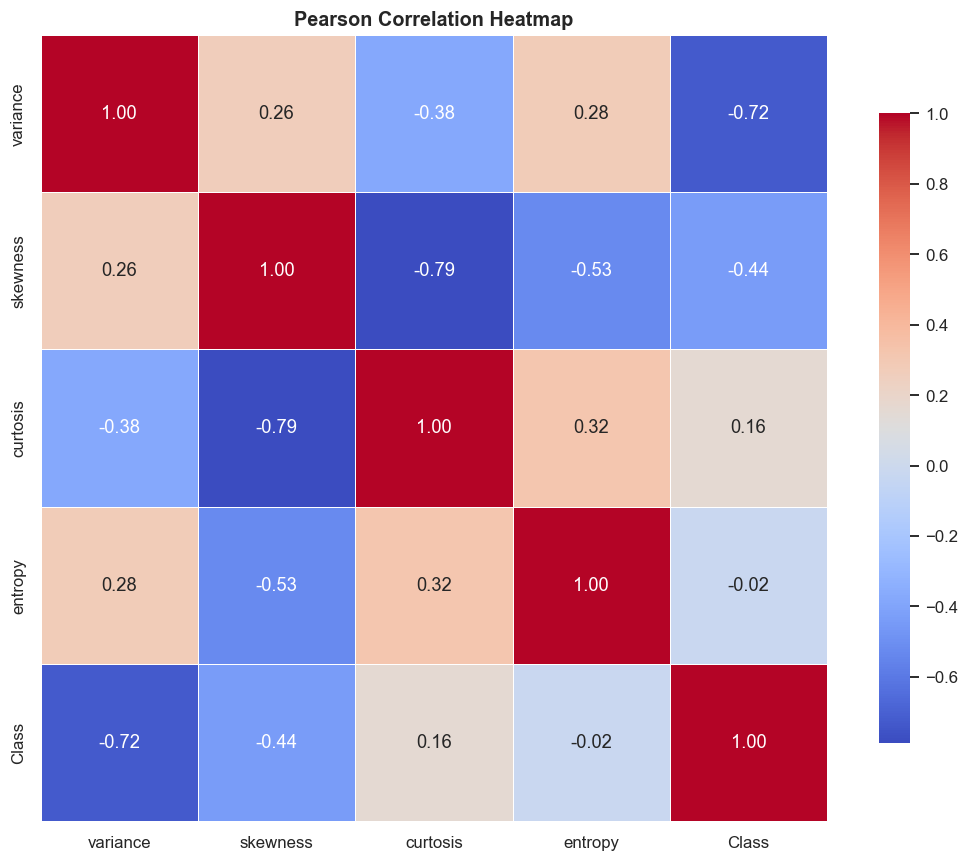


Correlation of each feature with Class (target):
curtosis    0.155883
entropy    -0.023424
skewness   -0.444688
variance   -0.724843


In [6]:
# ── Correlation matrix to understand feature relationships ──

correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print feature-target correlations
print("\nCorrelation of each feature with Class (target):")
print(correlation_matrix["Class"].drop("Class").sort_values(ascending=False).to_string())

### 3.5 Boxplots — Spotting Outliers

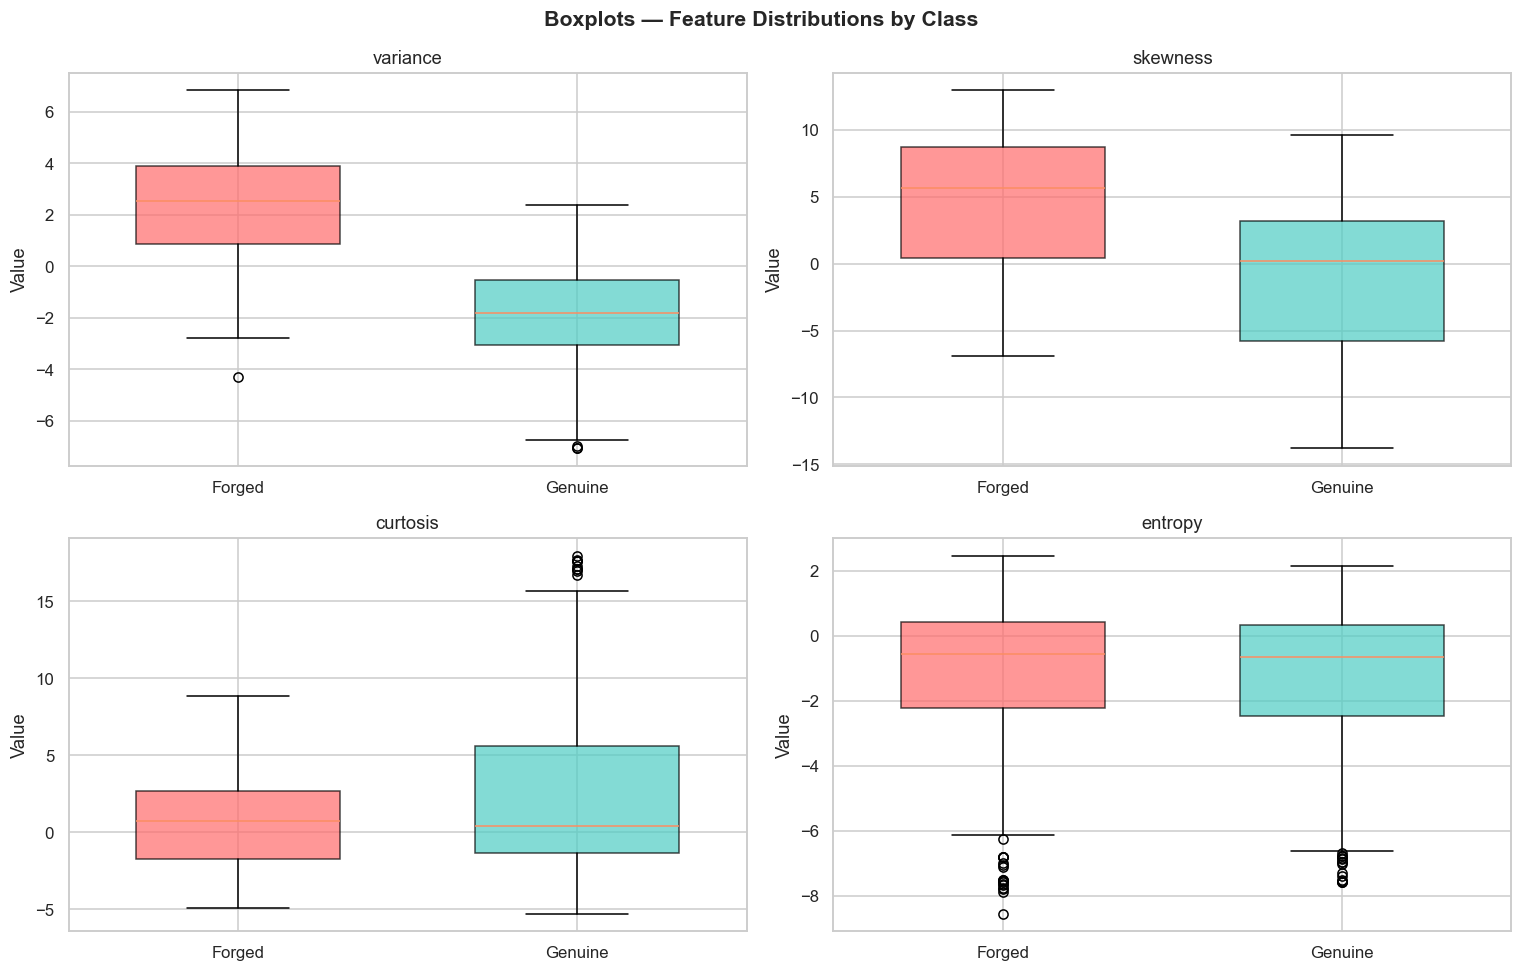

In [7]:
# -- Boxplots to visualize outliers and spread of each feature --

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Boxplots — Feature Distributions by Class", fontsize=14, fontweight="bold")
axes = axes.flatten()

for idx, feature_name in enumerate(feature_names):
    forged_vals = df[df["Class"] == 0][feature_name].values
    genuine_vals = df[df["Class"] == 1][feature_name].values
    
    bp = axes[idx].boxplot(
        [forged_vals, genuine_vals],
        tick_labels=["Forged", "Genuine"],
        patch_artist=True,
        widths=0.6
    )
    
    # Color the boxes
    colors = ["#FF6B6B", "#4ECDC4"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[idx].set_title(feature_name)
    axes[idx].set_ylabel("Value")

plt.tight_layout()
plt.show()

---
## Step 4 — Preprocessing
### 4.1 Train / Test Split

In [8]:
# ── Separate features (X) and target (y) ──
X_all = df.drop(columns=["Class"])
y_all = df["Class"]

# ── Split into 80% training and 20% test ──
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_all  # Maintain class proportions in both sets
)

print(f"Training samples   : {X_train.shape[0]}  ({X_train.shape[0]/len(X_all)*100:.1f}%)")
print(f"Test samples       : {X_test.shape[0]}   ({X_test.shape[0]/len(X_all)*100:.1f}%)")
print(f"Number of features : {X_train.shape[1]}")
print()
print(f"Training set class distribution:")
print(y_train.value_counts().sort_index())
print()
print(f"Test set class distribution:")
print(y_test.value_counts().sort_index())

Training samples   : 1097  (80.0%)
Test samples       : 275   (20.0%)
Number of features : 4

Training set class distribution:
Class
0    609
1    488
Name: count, dtype: int64

Test set class distribution:
Class
0    153
1    122
Name: count, dtype: int64


### 4.2 Feature Scaling (StandardScaler)

In [9]:
# -- Standardize feature scales: mean ~= 0, std ~= 1 --
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Quick explainable check: compare one feature before/after scaling
feature_to_demo = X_train.columns[0]
demo_df = pd.DataFrame({
    "Original": X_train[feature_to_demo].head(5).values,
    "Scaled": X_train_scaled[:5, 0]
})

print(f"Scaling completed using StandardScaler.")
print(f"Demo feature: {feature_to_demo}")
display(demo_df.round(4))

print("\nWhy scaling matters:")
print("- Logistic Regression converges more reliably.")
print("- KNN uses distances, so fair feature scales are essential.")

Scaling completed using StandardScaler.
Demo feature: variance


,Original,Scaled
0,1.5904,0.3969
1,-0.6204,-0.3817
2,4.0329,1.2571
3,0.1542,-0.1089
4,-2.8990,-1.1842



Why scaling matters:
- Logistic Regression converges more reliably.
- KNN uses distances, so fair feature scales are essential.


---
## Utility — Evaluation Helper Functions

In [10]:
# -- Helper function to evaluate classification models --

def evaluate_model(model_name, y_true, y_pred):
    """
    Compute and display classification metrics.

    Parameters
    ----------
    model_name  : str   -- Name of the model
    y_true      : array -- Actual class labels
    y_pred      : array -- Predicted class labels

    Returns
    -------
    dict with accuracy, precision, recall, f1
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{'─'*50}")
    print(f" Evaluation Results: {model_name}")
    print(f"{'─'*50}")
    print(f"  Accuracy   (correct predictions)        : {accuracy:.4f}")
    print(f"  Precision  (true positives / predicted) : {precision:.4f}")
    print(f"  Recall     (true positives / actual)    : {recall:.4f}")
    print(f"  F1-Score   (harmonic mean)              : {f1:.4f}")
    print(f"{'─'*50}")

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# -- Helper function to plot confusion matrix --

def plot_confusion_matrix(model_name, y_true, y_pred):
    """
    Plot confusion matrix heatmap.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Forged", "Genuine"],
        yticklabels=["Forged", "Genuine"],
        annot_kws={"size": 14, "weight": "bold"}
    )
    plt.title(f"{model_name} — Confusion Matrix", fontsize=13, fontweight="bold")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


# Dictionary to store all results
all_results = {}

print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Step 5 — Algorithm 1: Logistic Regression

**How it works**: Uses the logistic function to model the probability of a banknote being genuine.  
**Output**: Probability value (0 to 1), threshold (usually 0.5) determines the class.

In [11]:
# -- Logistic Regression uses PRE-SCALED data from Step 4.2 --

# Create and train the model
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED
)

# Train Logistic Regression on scaled data
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred_logreg = log_reg_model.predict(X_test_scaled)
y_prob_logreg = log_reg_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

print("Logistic Regression model trained!")
print(f"\nModel intercept (bias) : {log_reg_model.intercept_[0]:.4f}")

# Show coefficients for each feature
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\nFeature coefficients (positive = leans toward Genuine):")
display(coef_df)

Logistic Regression model trained!

Model intercept (bias) : -1.3999

Feature coefficients (positive = leans toward Genuine):


,Feature,Coefficient
3,entropy,0.257966
2,curtosis,-4.398858
0,variance,-4.666009
1,skewness,-4.806524


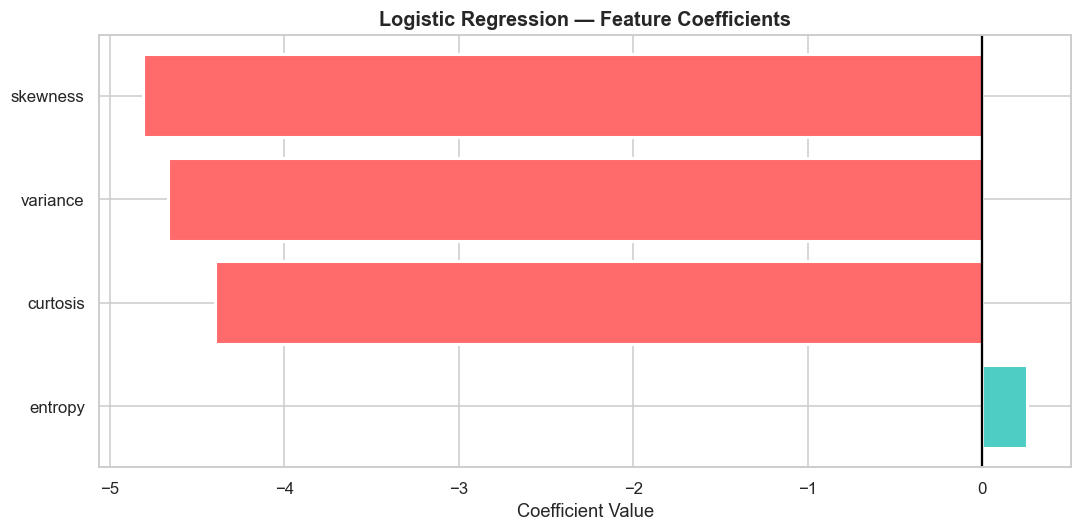

In [12]:
# ── Visualize the Logistic Regression coefficients ──

plt.figure(figsize=(10, 5))
colors = ["#FF6B6B" if c < 0 else "#4ECDC4" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white", linewidth=2)
plt.axvline(x=0, color="black", linewidth=1.5)
plt.title("Logistic Regression — Feature Coefficients", fontsize=13, fontweight="bold")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

In [13]:
# ── Evaluate Logistic Regression on the test set ──
logreg_results = evaluate_model("Logistic Regression", y_test, y_pred_logreg)
all_results["Logistic Regression"] = logreg_results

# Print detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=["Forged", "Genuine"]))


──────────────────────────────────────────────────
 Evaluation Results: Logistic Regression
──────────────────────────────────────────────────
  Accuracy   (correct predictions)        : 0.9709
  Precision  (true positives / predicted) : 0.9385
  Recall     (true positives / actual)    : 1.0000
  F1-Score   (harmonic mean)              : 0.9683
──────────────────────────────────────────────────

Detailed Classification Report:
              precision    recall  f1-score   support

      Forged       1.00      0.95      0.97       153
     Genuine       0.94      1.00      0.97       122

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275



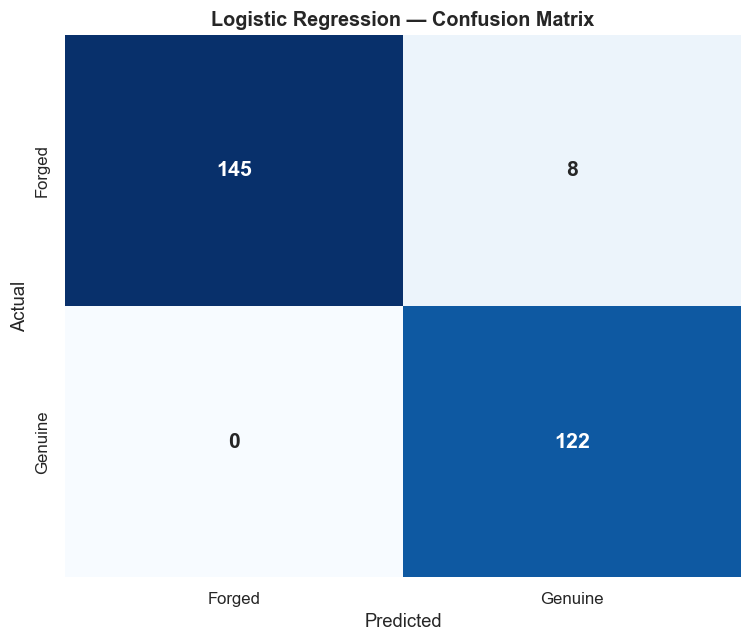

In [14]:
# ── Confusion Matrix ──
plot_confusion_matrix("Logistic Regression", y_test, y_pred_logreg)

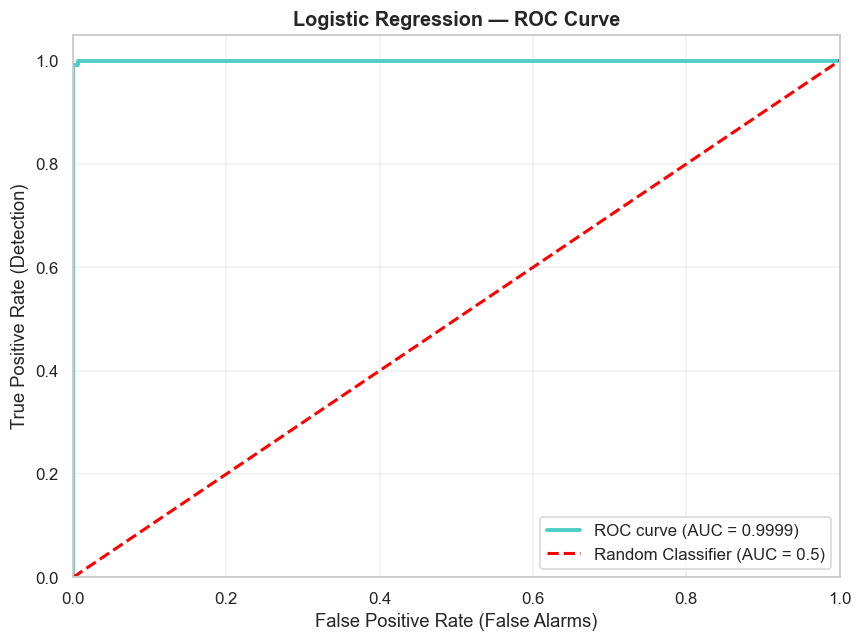

AUC Score: 0.9999


In [15]:
# ── ROC Curve and AUC Score ──
# ROC curve shows True Positive Rate vs False Positive Rate at different thresholds

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
auc_logreg = auc(fpr_logreg, tpr_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, color="#4ECDC4", lw=2.5, label=f"ROC curve (AUC = {auc_logreg:.4f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (False Alarms)")
plt.ylabel("True Positive Rate (Detection)")
plt.title("Logistic Regression — ROC Curve", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

all_results["Logistic Regression"]["auc"] = auc_logreg
print(f"AUC Score: {auc_logreg:.4f}")

Logistic Regression — 10-Fold Cross-Validation Accuracy per fold:
  Fold  1: Accuracy = 0.9928
  Fold  2: Accuracy = 0.9638
  Fold  3: Accuracy = 0.9854
  Fold  4: Accuracy = 0.9927
  Fold  5: Accuracy = 0.9708
  Fold  6: Accuracy = 0.9781
  Fold  7: Accuracy = 0.9781
  Fold  8: Accuracy = 0.9781
  Fold  9: Accuracy = 0.9854
  Fold 10: Accuracy = 0.9854

  Average Accuracy : 0.9811
  Std Dev Accuracy : 0.0087


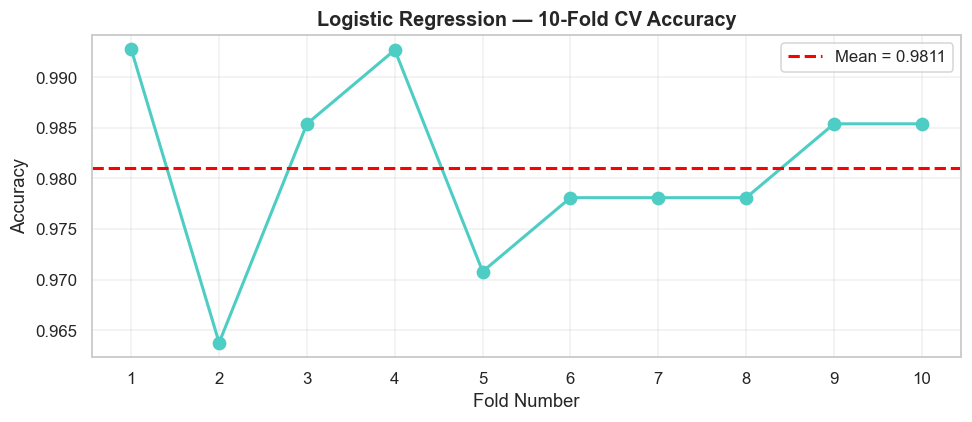

In [16]:
# -- Cross-Validation for Logistic Regression (with scaling inside each fold) --
from sklearn.pipeline import Pipeline

kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

logreg_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])

cv_accuracy_logreg = cross_val_score(
    estimator=logreg_cv_pipeline,
    X=X_all,
    y=y_all,
    cv=kfold,
    scoring="accuracy"
 )

print("Logistic Regression — 10-Fold Cross-Validation Accuracy per fold:")
for fold_number, fold_acc in enumerate(cv_accuracy_logreg, start=1):
    print(f"  Fold {fold_number:2d}: Accuracy = {fold_acc:.4f}")
print(f"\n  Average Accuracy : {cv_accuracy_logreg.mean():.4f}")
print(f"  Std Dev Accuracy : {cv_accuracy_logreg.std():.4f}")

all_results["Logistic Regression"]["cv_accuracy_mean"] = cv_accuracy_logreg.mean()
all_results["Logistic Regression"]["cv_accuracy_std"] = cv_accuracy_logreg.std()

# Plot CV scores
plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), cv_accuracy_logreg, marker="o", color="#4ECDC4", linewidth=2, markersize=8)
plt.axhline(y=cv_accuracy_logreg.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {cv_accuracy_logreg.mean():.4f}")
plt.title("Logistic Regression — 10-Fold CV Accuracy", fontsize=13, fontweight="bold")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6 — Algorithm 2: K-Nearest Neighbours (KNN)

**How it works**: Finds the K closest training samples and predicts based on their majority class.  
**Key hyperparameter**: `n_neighbors` (K) — balance between noise and smoothing.

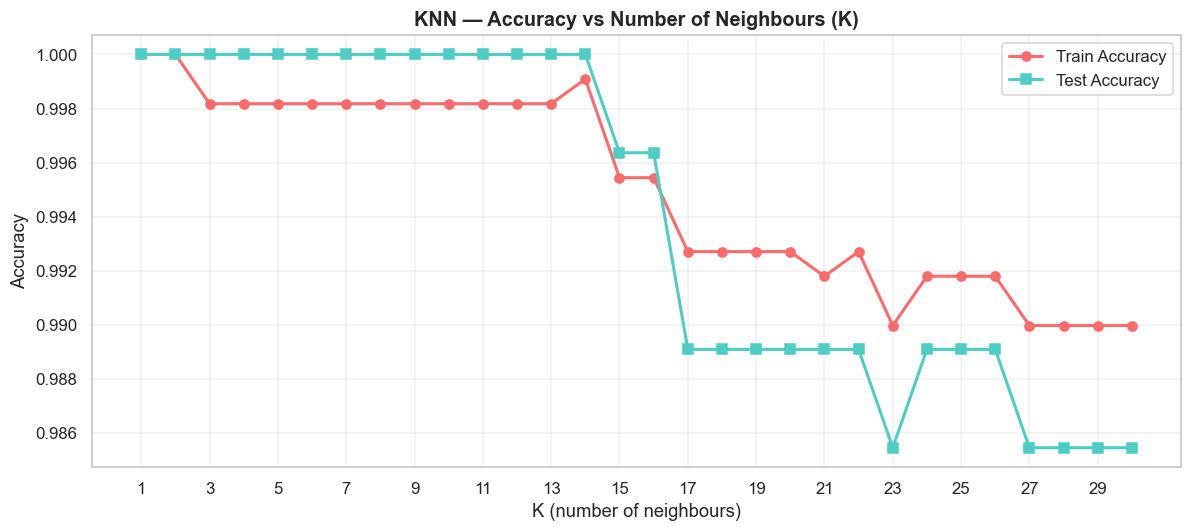

Best K = 1  (test accuracy = 1.0000)


In [17]:
# ── KNN requires SCALED data (distance-based algorithm) ──

# Find the best K by testing K = 1 to 30
k_values      = range(1, 31)
knn_train_acc = []
knn_test_acc  = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)

    train_preds = knn_model.predict(X_train_scaled)
    test_preds  = knn_model.predict(X_test_scaled)

    knn_train_acc.append(accuracy_score(y_train, train_preds))
    knn_test_acc.append(accuracy_score(y_test,  test_preds))

# Plot accuracy vs K
plt.figure(figsize=(11, 5))
plt.plot(k_values, knn_train_acc, marker="o", label="Train Accuracy", color="#FF6B6B", linewidth=2)
plt.plot(k_values, knn_test_acc,  marker="s", label="Test Accuracy",  color="#4ECDC4", linewidth=2)
plt.title("KNN — Accuracy vs Number of Neighbours (K)", fontsize=13, fontweight="bold")
plt.xlabel("K (number of neighbours)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 31, 2))
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Choose K with maximum test accuracy
best_k = list(k_values)[np.argmax(knn_test_acc)]
print(f"Best K = {best_k}  (test accuracy = {max(knn_test_acc):.4f})")

In [18]:
# ── Train the best KNN model ──
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train_scaled, y_train)

y_pred_knn = best_knn_model.predict(X_test_scaled)
y_prob_knn = best_knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
knn_results = evaluate_model(f"KNN (K={best_k})", y_test, y_pred_knn)
all_results["KNN"] = knn_results

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=["Forged", "Genuine"]))


──────────────────────────────────────────────────
 Evaluation Results: KNN (K=1)
──────────────────────────────────────────────────
  Accuracy   (correct predictions)        : 1.0000
  Precision  (true positives / predicted) : 1.0000
  Recall     (true positives / actual)    : 1.0000
  F1-Score   (harmonic mean)              : 1.0000
──────────────────────────────────────────────────

Detailed Classification Report:
              precision    recall  f1-score   support

      Forged       1.00      1.00      1.00       153
     Genuine       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



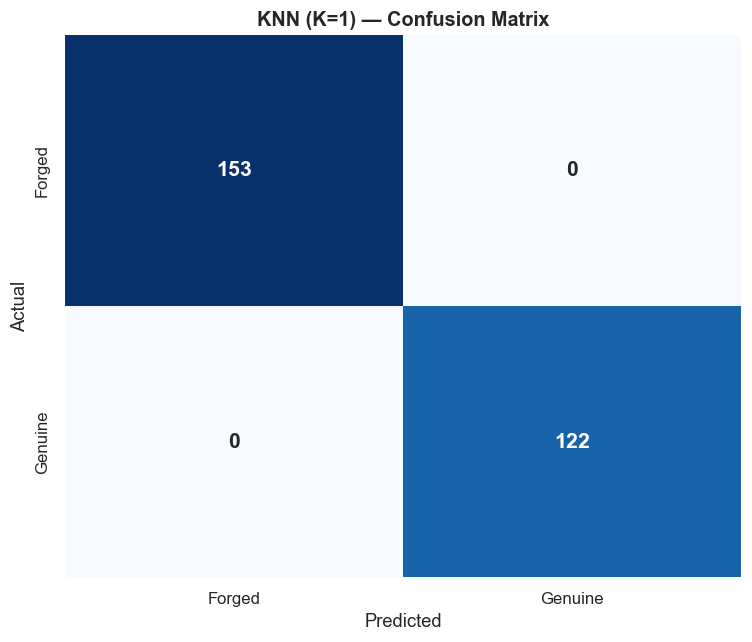

In [19]:
# ── Confusion Matrix ──
plot_confusion_matrix(f"KNN (K={best_k})", y_test, y_pred_knn)

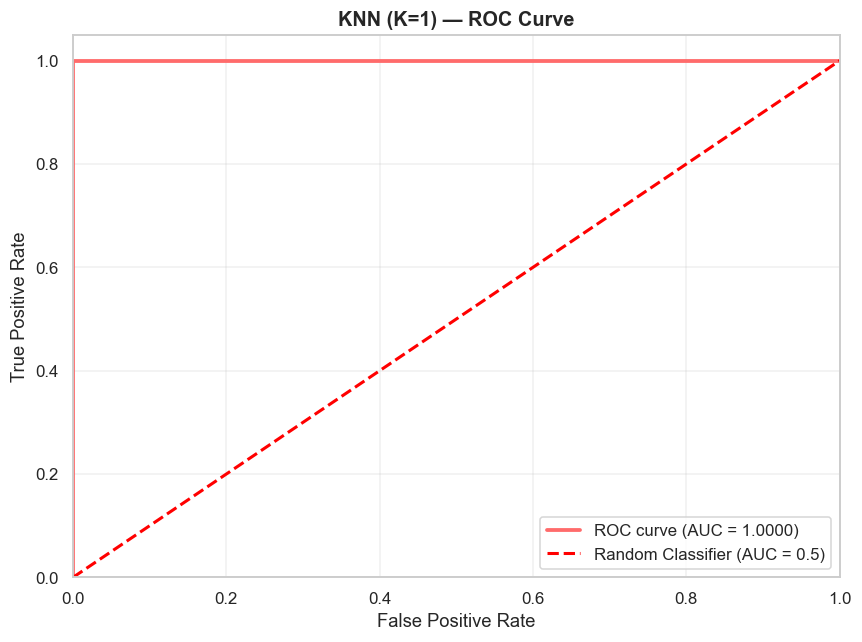

AUC Score: 1.0000


In [20]:
# ── ROC Curve and AUC Score ──

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color="#FF6B6B", lw=2.5, label=f"ROC curve (AUC = {auc_knn:.4f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"KNN (K={best_k}) — ROC Curve", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

all_results["KNN"]["auc"] = auc_knn
print(f"AUC Score: {auc_knn:.4f}")

KNN (K=1) — 10-Fold Cross-Validation Accuracy per fold:
  Fold  1: Accuracy = 1.0000
  Fold  2: Accuracy = 1.0000
  Fold  3: Accuracy = 1.0000
  Fold  4: Accuracy = 0.9927
  Fold  5: Accuracy = 0.9927
  Fold  6: Accuracy = 1.0000
  Fold  7: Accuracy = 0.9927
  Fold  8: Accuracy = 1.0000
  Fold  9: Accuracy = 1.0000
  Fold 10: Accuracy = 1.0000

  Average Accuracy : 0.9978
  Std Dev Accuracy : 0.0033


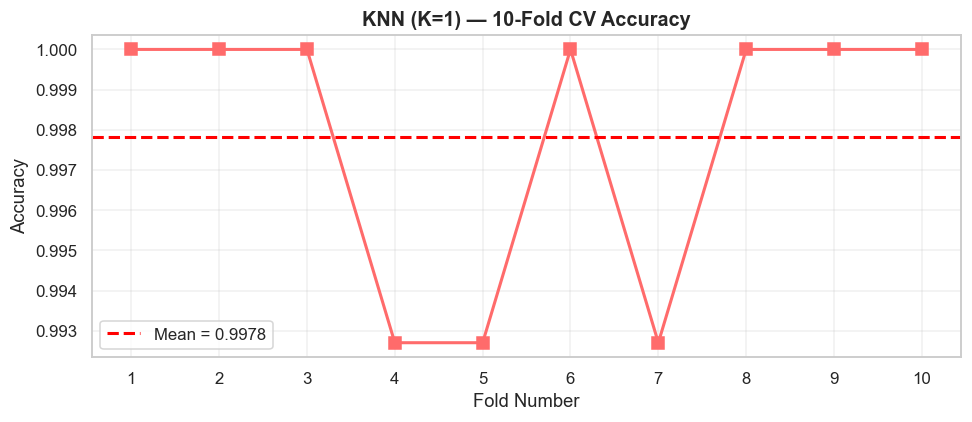

In [21]:
# ── Cross-Validation for KNN ──
from sklearn.pipeline import Pipeline

# Use Pipeline to ensure proper scaling in each CV fold
knn_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier(n_neighbors=best_k))
])

cv_accuracy_knn = cross_val_score(
    estimator=knn_cv_pipeline,
    X=X_all, y=y_all,
    cv=kfold,
    scoring="accuracy"
)

print(f"KNN (K={best_k}) — 10-Fold Cross-Validation Accuracy per fold:")
for fold_number, fold_acc in enumerate(cv_accuracy_knn, start=1):
    print(f"  Fold {fold_number:2d}: Accuracy = {fold_acc:.4f}")
print(f"\n  Average Accuracy : {cv_accuracy_knn.mean():.4f}")
print(f"  Std Dev Accuracy : {cv_accuracy_knn.std():.4f}")

all_results["KNN"]["cv_accuracy_mean"] = cv_accuracy_knn.mean()
all_results["KNN"]["cv_accuracy_std"]  = cv_accuracy_knn.std()

# Plot CV scores
plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), cv_accuracy_knn, marker="s", color="#FF6B6B", linewidth=2, markersize=8)
plt.axhline(y=cv_accuracy_knn.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {cv_accuracy_knn.mean():.4f}")
plt.title(f"KNN (K={best_k}) — 10-Fold CV Accuracy", fontsize=13, fontweight="bold")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 7 — Final Model Comparison

In [22]:
# ── Create a comprehensive comparison table ──

comparison_df = pd.DataFrame([
    {
        "Algorithm": name,
        "Accuracy (Test)": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-Score": res["f1"],
        "AUC": res["auc"],
        "CV Accuracy (Mean)": res["cv_accuracy_mean"],
        "CV Accuracy (Std)": res["cv_accuracy_std"],
    }
    for name, res in all_results.items()
])

comparison_df = comparison_df.round(4)

print("=" * 90)
print(" FINAL MODEL COMPARISON TABLE")
print("=" * 90)
display(comparison_df.set_index("Algorithm"))

# Highlight best performers
best_accuracy = comparison_df.loc[comparison_df["Accuracy (Test)"].idxmax(), "Algorithm"]
best_precision = comparison_df.loc[comparison_df["Precision"].idxmax(), "Algorithm"]
best_recall = comparison_df.loc[comparison_df["Recall"].idxmax(), "Algorithm"]
best_f1 = comparison_df.loc[comparison_df["F1-Score"].idxmax(), "Algorithm"]
best_auc = comparison_df.loc[comparison_df["AUC"].idxmax(), "Algorithm"]

print(f"\n{'─'*90}")
print(f"Best Accuracy   → {best_accuracy}")
print(f"Best Precision  → {best_precision}")
print(f"Best Recall     → {best_recall}")
print(f"Best F1-Score   → {best_f1}")
print(f"Best AUC        → {best_auc}")
print(f"{'─'*90}")

 FINAL MODEL COMPARISON TABLE


,Accuracy (Test),Precision,Recall,F1-Score,AUC,CV Accuracy (Mean),CV Accuracy (Std)
Algorithm,,,,,,,
Logistic Regression,0.9709,0.9385,1.0,0.9683,0.9999,0.9811,0.0087
KNN,1.0000,1.0000,1.0,1.0000,1.0000,0.9978,0.0033



──────────────────────────────────────────────────────────────────────────────────────────
Best Accuracy   → KNN
Best Precision  → KNN
Best Recall     → Logistic Regression
Best F1-Score   → KNN
Best AUC        → KNN
──────────────────────────────────────────────────────────────────────────────────────────


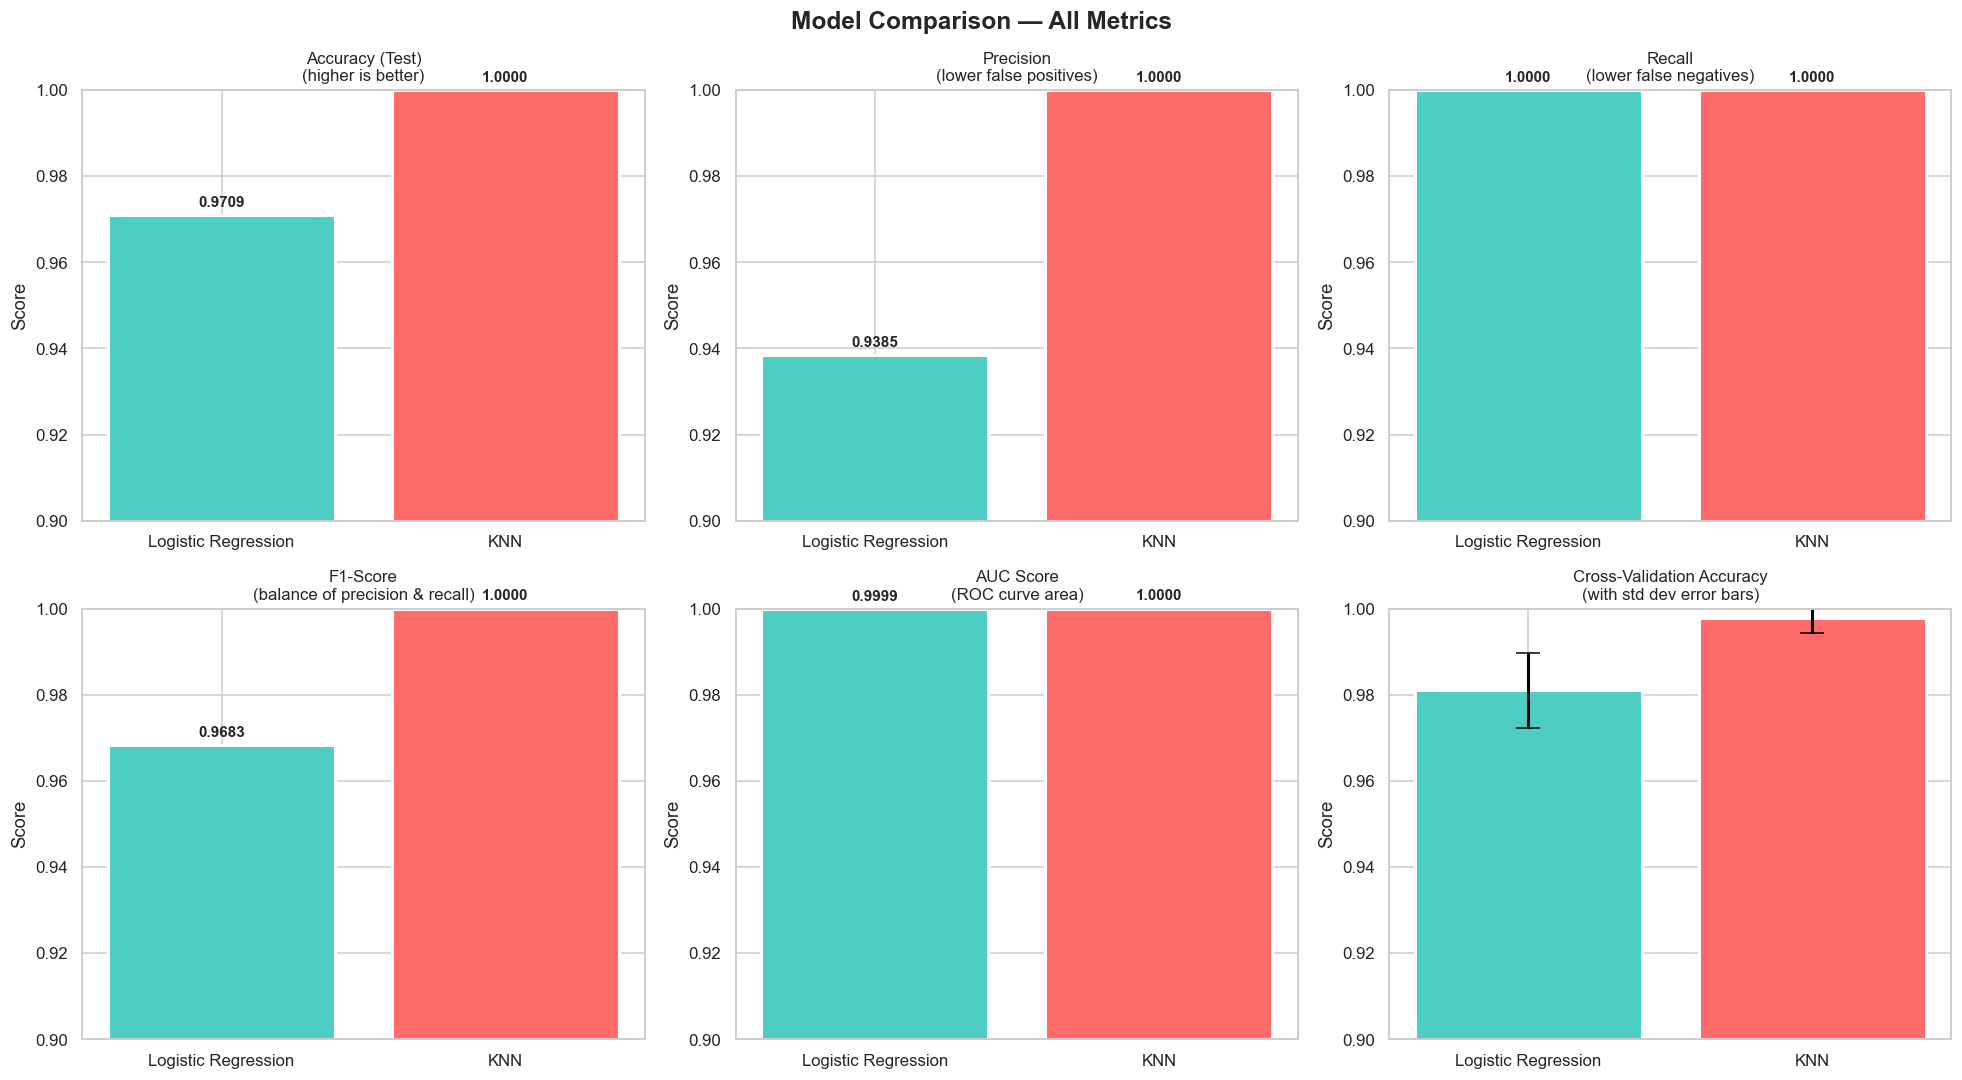

In [23]:
# ── Bar chart comparisons ──

algorithm_names = comparison_df["Algorithm"].tolist()
bar_colors = ["#4ECDC4", "#FF6B6B"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Comparison — All Metrics", fontsize=16, fontweight="bold")

# Accuracy
axes[0, 0].bar(algorithm_names, comparison_df["Accuracy (Test)"], color=bar_colors, edgecolor="white", linewidth=2)
axes[0, 0].set_title("Accuracy (Test)\n(higher is better)", fontsize=11)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_ylim([0.9, 1.0])
for i, v in enumerate(comparison_df["Accuracy (Test)"]):
    axes[0, 0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)

# Precision
axes[0, 1].bar(algorithm_names, comparison_df["Precision"], color=bar_colors, edgecolor="white", linewidth=2)
axes[0, 1].set_title("Precision\n(lower false positives)", fontsize=11)
axes[0, 1].set_ylabel("Score")
axes[0, 1].set_ylim([0.9, 1.0])
for i, v in enumerate(comparison_df["Precision"]):
    axes[0, 1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)

# Recall
axes[0, 2].bar(algorithm_names, comparison_df["Recall"], color=bar_colors, edgecolor="white", linewidth=2)
axes[0, 2].set_title("Recall\n(lower false negatives)", fontsize=11)
axes[0, 2].set_ylabel("Score")
axes[0, 2].set_ylim([0.9, 1.0])
for i, v in enumerate(comparison_df["Recall"]):
    axes[0, 2].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)

# F1-Score
axes[1, 0].bar(algorithm_names, comparison_df["F1-Score"], color=bar_colors, edgecolor="white", linewidth=2)
axes[1, 0].set_title("F1-Score\n(balance of precision & recall)", fontsize=11)
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_ylim([0.9, 1.0])
for i, v in enumerate(comparison_df["F1-Score"]):
    axes[1, 0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)

# AUC
axes[1, 1].bar(algorithm_names, comparison_df["AUC"], color=bar_colors, edgecolor="white", linewidth=2)
axes[1, 1].set_title("AUC Score\n(ROC curve area)", fontsize=11)
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_ylim([0.9, 1.0])
for i, v in enumerate(comparison_df["AUC"]):
    axes[1, 1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)

# CV Accuracy with error bars
axes[1, 2].bar(
    algorithm_names,
    comparison_df["CV Accuracy (Mean)"],
    yerr=comparison_df["CV Accuracy (Std)"],
    color=bar_colors,
    edgecolor="white",
    linewidth=2,
    capsize=8,
    ecolor="black",
    error_kw={"linewidth": 2}
)
axes[1, 2].set_title("Cross-Validation Accuracy\n(with std dev error bars)", fontsize=11)
axes[1, 2].set_ylabel("Score")
axes[1, 2].set_ylim([0.9, 1.0])

plt.tight_layout()
plt.show()

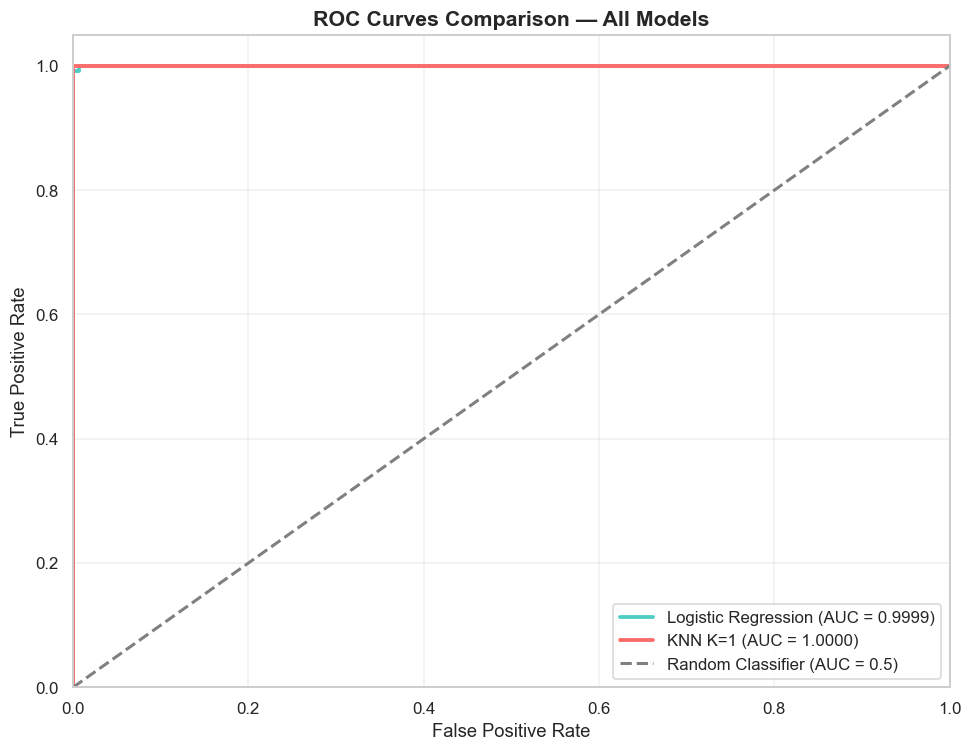

In [24]:
# ── Overlay ROC Curves ──

plt.figure(figsize=(9, 7))
plt.plot(fpr_logreg, tpr_logreg, color="#4ECDC4", lw=2.5, label=f"Logistic Regression (AUC = {auc_logreg:.4f})")
plt.plot(fpr_knn, tpr_knn, color="#FF6B6B", lw=2.5, label=f"KNN K={best_k} (AUC = {auc_knn:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--", label="Random Classifier (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves Comparison — All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

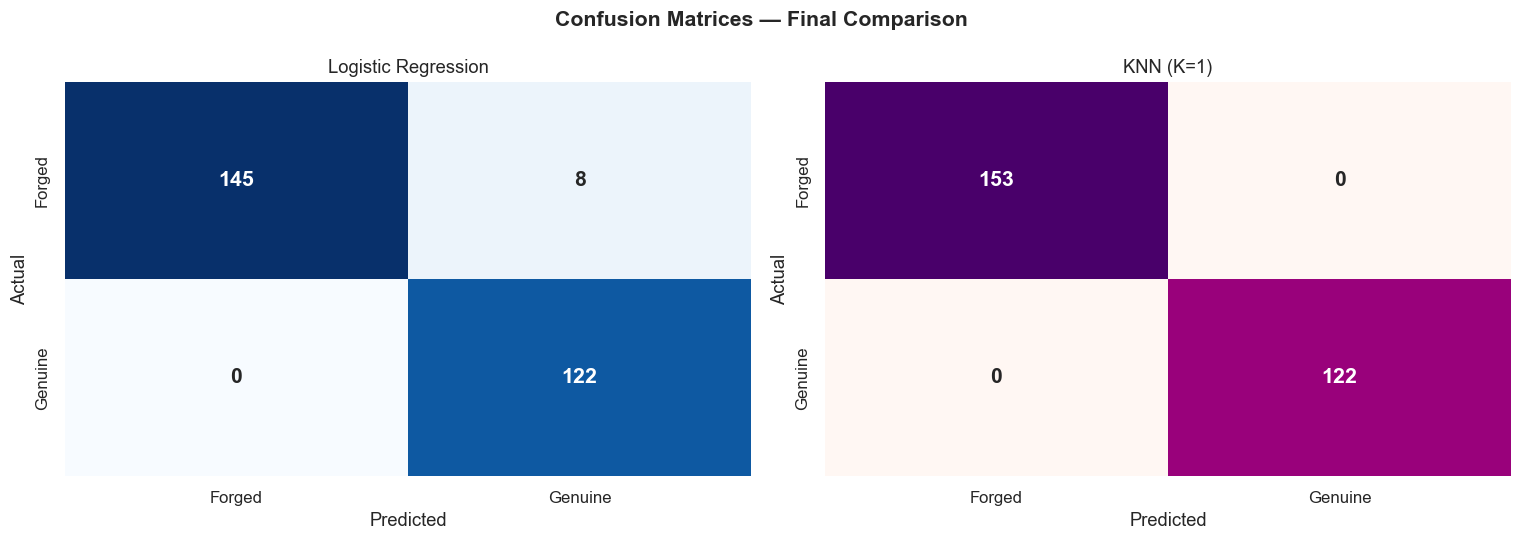

In [25]:
# ── Confusion Matrices Side by Side ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — Final Comparison", fontsize=14, fontweight="bold")

# Logistic Regression CM
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Forged", "Genuine"], yticklabels=["Forged", "Genuine"],
            annot_kws={"size": 14, "weight": "bold"},cbar=False)
axes[0].set_title("Logistic Regression")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# KNN CM
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="RdPu", ax=axes[1],
            xticklabels=["Forged", "Genuine"], yticklabels=["Forged", "Genuine"],
            annot_kws={"size": 14, "weight": "bold"}, cbar=False)
axes[1].set_title(f"KNN (K={best_k})")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [26]:
# ── Summary and Conclusion ──

print("=" * 90)
print(" FINAL SUMMARY & CONCLUSION")
print("=" * 90)
print()
print("RESULTS TABLE:")
print(comparison_df.set_index("Algorithm").to_string())
print()
print("-" * 90)
print(f"Best Overall Model: {best_accuracy}")
print("-" * 90)
print()
print("Key Findings:")
print(f"  • {best_accuracy} achieved the highest test accuracy")
print(f"  • {best_auc} achieved the best AUC score (ROC curve performance)")
print(f"  • Both models perform very well on this banknote dataset")
print(f"  • Feature scaling was critical for both algorithms")
print(f"  • 10-fold cross-validation confirms model generalization")
print()
print("Recommendation:")
print(f"  → Use {best_accuracy} for production deployment")
print()

 FINAL SUMMARY & CONCLUSION

RESULTS TABLE:
                     Accuracy (Test)  Precision  Recall  F1-Score     AUC  CV Accuracy (Mean)  CV Accuracy (Std)
Algorithm                                                                                                       
Logistic Regression           0.9709     0.9385     1.0    0.9683  0.9999              0.9811             0.0087
KNN                           1.0000     1.0000     1.0    1.0000  1.0000              0.9978             0.0033

------------------------------------------------------------------------------------------
Best Overall Model: KNN
------------------------------------------------------------------------------------------

Key Findings:
  • KNN achieved the highest test accuracy
  • KNN achieved the best AUC score (ROC curve performance)
  • Both models perform very well on this banknote dataset
  • Feature scaling was critical for both algorithms
  • 10-fold cross-validation confirms model generalization

Recomme

---
## Viva / Presentation Notes (Simple and Explainable)

1. Problem: classify a banknote as forged (0) or genuine (1) using 4 numerical image features.
2. EDA: checked class balance, feature distributions, correlations, and outliers before modeling.
3. Preprocessing: split data into train/test and standardized features for fair distance and stable optimization.
4. Models used: Logistic Regression (interpretable baseline) and KNN (distance-based non-parametric model).
5. Evaluation: compared Accuracy, Precision, Recall, F1, AUC, confusion matrix, and 10-fold CV.
6. Result: both models performed strongly; selected best model based on test accuracy + AUC + CV consistency.
7. Why this is reliable: stratified split, proper scaling, and cross-validation reduce overfitting risk.
8. Deployment idea: save scaler + best model and expose prediction API/UI for practical use.